<a href="https://colab.research.google.com/github/ajaykumar080286/DeepLearning/blob/master/22_zero_initialization_sigmoid.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense,Dropout
from keras.optimizers import Adam

from mlxtend.plotting import plot_decision_regions

In [2]:
df=pd.read_csv("https://raw.githubusercontent.com/ajaykumar080286/DeepLearning/master/ushape.csv")

In [3]:
df=df.round(2)

In [4]:
df.head()

,X,Y,class
0,0.03,0.99,0.0
1,2.12,-0.05,1.0
2,0.88,-0.08,0.0
3,-0.06,-0.04,1.0
4,0.83,-0.54,1.0


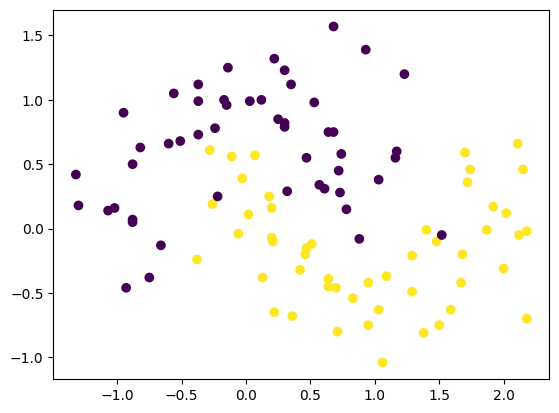

In [5]:
plt.scatter(df["X"],df["Y"],c=df["class"])

In [6]:
X=df.iloc[:,0:2]
y=df.iloc[:,-1]

In [8]:
model=Sequential()
model.add(Dense(10,activation="sigmoid", input_dim=2))
model.add(Dense(1,activation="sigmoid"))

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 41 (164.00 B)

 Trainable params: 41 (164.00 B)

 Non-trainable params: 0 (0.00 B)

In [9]:
model.get_weights()

[array([[-0.1678409 ,  0.512551  , -0.22777218,  0.5393693 ,  0.4714653 ,
          0.09715605, -0.23618469,  0.2180152 ,  0.6584988 ,  0.66401786],
        [-0.34876212,  0.00512975, -0.18032885,  0.09141886,  0.20897013,
          0.43378717,  0.63900787,  0.17282754, -0.49801844,  0.463149  ]],
       dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[ 0.2780115 ],
        [ 0.70537704],
        [ 0.22583467],
        [-0.30480438],
        [ 0.63349015],
        [-0.62309575],
        [ 0.22950709],
        [ 0.52506596],
        [ 0.5018007 ],
        [-0.68235797]], dtype=float32),
 array([0.], dtype=float32)]

In [10]:
initial_weights = model.get_weights()

In [11]:
initial_weights[0]=np.zeros(model.get_weights()[0].shape)*0.5
initial_weights[1]=np.zeros(model.get_weights()[1].shape)*0.5
initial_weights[2]=np.zeros(model.get_weights()[2].shape)*0.5
initial_weights[3]=np.zeros(model.get_weights()[3].shape)*0.5

In [12]:
model.set_weights(initial_weights)

In [13]:
initial_weights

[array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]]),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]),
 array([[0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.]]),
 array([0.])]

In [14]:
model.compile(optimizer='Adam', loss='binary_crossentropy', metrics=['accuracy'])

In [15]:
history=model.fit(X,y,epochs=100, validation_split=0.2)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 125ms/step - accuracy: 0.5000 - loss: 0.6936 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.5000 - loss: 0.6931 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.5000 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.4750 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.5000 - loss: 0.6931 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.5000 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.5000 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.4750 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 17s 2ms/step


<Axes: >

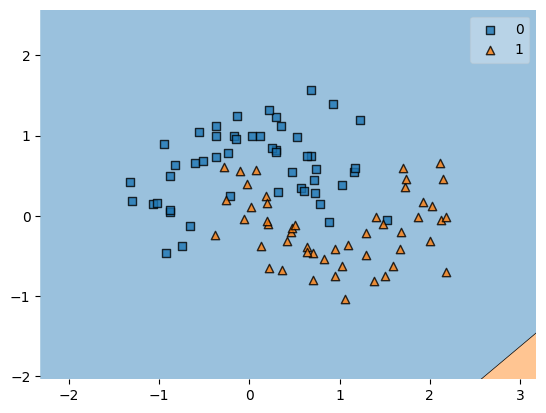

In [16]:
plot_decision_regions(X.values,y.values.astype('int'),model)

In [18]:
model.get_weights() # all set of weights are same if sigmoid with zero initial

[array([[-0.45057917, -0.45057917, -0.45057917, -0.45057917, -0.45057917,
         -0.45057917, -0.45057917, -0.45057917, -0.45057917, -0.45057917],
        [ 0.47689232,  0.47689232,  0.47689232,  0.47689232,  0.47689232,
          0.47689232,  0.47689232,  0.47689232,  0.47689232,  0.47689232]],
       dtype=float32),
 array([-0.10262214, -0.10262214, -0.10262214, -0.10262214, -0.10262214,
        -0.10262214, -0.10262214, -0.10262214, -0.10262214, -0.10262214],
       dtype=float32),
 array([[-0.06596462],
        [-0.06596462],
        [-0.06596462],
        [-0.06596462],
        [-0.06596462],
        [-0.06596462],
        [-0.06596462],
        [-0.06596462],
        [-0.06596462],
        [-0.06596462]], dtype=float32),
 array([0.06390517], dtype=float32)]